In [203]:
import numpy as np
from matplotlib import pyplot as plt
import math

# Calculate track spline interpolation via Wikipedia's algorithm implementation

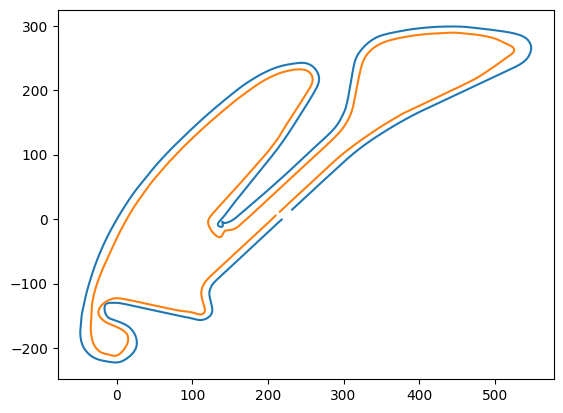

In [204]:
import splines
import generate_track

interpolated_points_count = 2000

cones_left_x, cones_left_y, cones_right_x, cones_right_y = generate_track.generate()
left_param = np.empty(*cones_left_x.shape)
right_param = np.empty(*cones_right_x.shape)

left_param[0] = 0  # first cone distance is 0
right_param[0] = 0

# calculate L2 distance as a parameter
for index in range(1, len(left_param)):
    left_param[index] = left_param[index - 1]
    left_param[index] += math.sqrt((cones_left_x[index] - cones_left_x[index - 1]) ** 2 + \
                                       (cones_left_y[index] - cones_left_y[index - 1]) ** 2)

for index in range(1, len(right_param)):
    right_param[index] = right_param[index - 1]
    right_param[index] += math.sqrt((cones_right_x[index] - cones_right_x[index - 1]) ** 2 + \
                                        (cones_right_y[index] - cones_right_y[index - 1]) ** 2)

    # calculate parametric splines
right_x_spline = splines.CubicSpline(right_param, cones_right_x)
right_y_spline = splines.CubicSpline(right_param, cones_right_y)
left_x_spline = splines.CubicSpline(left_param, cones_left_x)
left_y_spline = splines.CubicSpline(left_param, cones_left_y)

t_plot_left = np.linspace(0, max(left_param), interpolated_points_count)
t_plot_right = np.linspace(0, max(right_param), interpolated_points_count)

restored_x_left = left_x_spline.get_range(t_plot_left)
restored_y_left = left_y_spline.get_range(t_plot_left)
restored_x_right = right_x_spline.get_range(t_plot_right)
restored_y_right = right_y_spline.get_range(t_plot_right)

plt.plot(restored_x_right, restored_y_right)
plt.plot(restored_x_left, restored_y_left)

# Calculate track spline interpolation via SciPy's algorihm

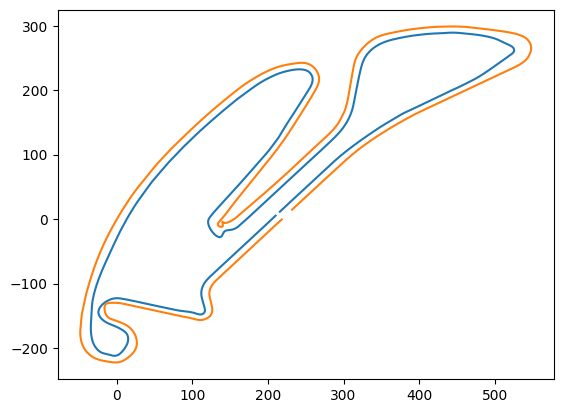

In [205]:
from scipy.interpolate import CubicSpline

# uses parameters calculated above

scipy_left_x_spline = CubicSpline(left_param, cones_left_x, bc_type='not-a-knot')
scipy_left_y_spline = CubicSpline(left_param, cones_left_y, bc_type='not-a-knot')
scipy_right_x_spline = CubicSpline(right_param, cones_right_x, bc_type='not-a-knot')
scipy_right_y_spline = CubicSpline(right_param, cones_right_y, bc_type='not-a-knot')

scipy_restored_x_left = scipy_left_x_spline(t_plot_left)
scipy_restored_y_left = scipy_left_y_spline(t_plot_left)
scipy_restored_x_right = scipy_right_x_spline(t_plot_right)
scipy_restored_y_right = scipy_right_y_spline(t_plot_right)

plt.plot(scipy_restored_x_left, scipy_restored_y_left)
plt.plot(scipy_restored_x_right, scipy_restored_y_right)

## Use the natural algorithm

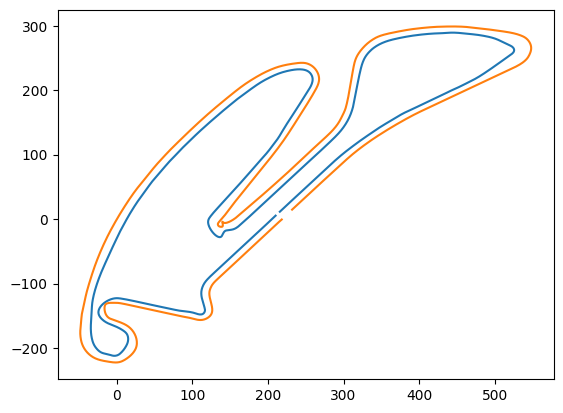

In [206]:
scipy_left_x_spline_natural = CubicSpline(left_param, cones_left_x, bc_type='natural')
scipy_left_y_spline_natural = CubicSpline(left_param, cones_left_y, bc_type='natural')
scipy_right_x_spline_natural = CubicSpline(right_param, cones_right_x, bc_type='natural')
scipy_right_y_spline_natural = CubicSpline(right_param, cones_right_y, bc_type='natural')

scipy_restored_x_left_natural = scipy_left_x_spline_natural(t_plot_left)
scipy_restored_y_left_natural = scipy_left_y_spline_natural(t_plot_left)
scipy_restored_x_right_natural = scipy_right_x_spline_natural(t_plot_right)
scipy_restored_y_right_natural = scipy_right_y_spline_natural(t_plot_right)

plt.plot(scipy_restored_x_left_natural, scipy_restored_y_left_natural)
plt.plot(scipy_restored_x_right_natural, scipy_restored_y_right_natural)

# Overlay and compare

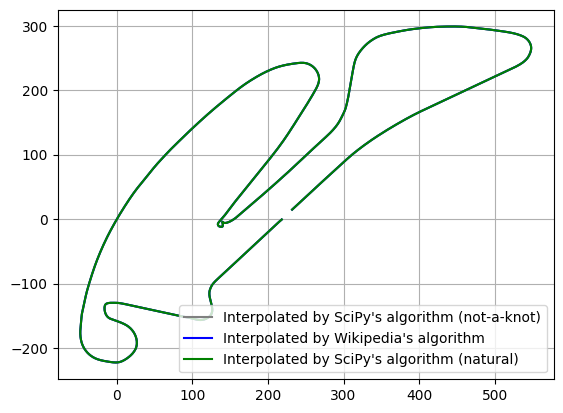

In [207]:
plt.plot(scipy_restored_x_right, scipy_restored_y_right, color='gray', label="Interpolated by SciPy's algorithm (not-a-knot)")
plt.plot(restored_x_right, restored_y_right, color='blue', label="Interpolated by Wikipedia's algorithm")
plt.plot(scipy_restored_x_right_natural, scipy_restored_y_right_natural, color='green', label="Interpolated by SciPy's algorithm (natural)")
plt.legend()
plt.grid()
plt.show()

Notice that:
- strangely, all algorithms seem to produce roughly the same results, **even when comparing not-a-knot to natural**
- own implementation from Wikipedia seems to work mostly fine, though ***there are some artifacts to remove***

## Compare calculated derivatives

In [208]:
# Not-a-knot derivatives
scipy_right_x_derivative_spline = scipy_right_x_spline.derivative()
scipy_right_y_derivative_spline = scipy_right_y_spline.derivative()
scipy_right_x_derivative = scipy_right_x_derivative_spline(t_plot_right)
scipy_right_y_derivative = scipy_right_y_derivative_spline(t_plot_right)
# Natural derivatives
scipy_natural_right_x_derivative_spline = scipy_right_x_spline_natural.derivative()
scipy_natural_right_y_derivative_spline = scipy_right_y_spline_natural.derivative()
scipy_natural_right_x_derivative = scipy_natural_right_x_derivative_spline(t_plot_right)
scipy_natural_right_y_derivative = scipy_natural_right_y_derivative_spline(t_plot_right)
# Wikipedia's derivatives
wikipedia_right_x = np.empty_like(t_plot_right)
wikipedia_right_y = np.empty_like(t_plot_right)
for index in range(len(t_plot_right)):
    wikipedia_right_x[index] = right_x_spline.get_derivative_at(t_plot_right[index])
    wikipedia_right_y[index] = right_y_spline.get_derivative_at(t_plot_right[index])

### Plot dx/dt

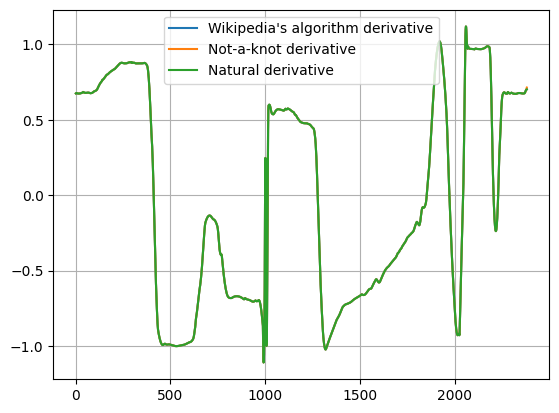

In [209]:
plt.plot(t_plot_right, wikipedia_right_x, label="Wikipedia's algorithm derivative")
plt.plot(t_plot_right, scipy_right_x_derivative, label='Not-a-knot derivative')
plt.plot(t_plot_right, scipy_natural_right_x_derivative, label='Natural derivative')

plt.legend()
plt.grid()
plt.show()

### Plot dy/dt

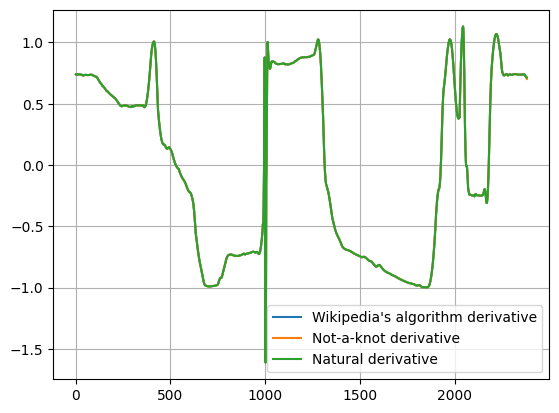

In [210]:
plt.plot(t_plot_right, wikipedia_right_y, label="Wikipedia's algorithm derivative")
plt.plot(t_plot_right, scipy_right_y_derivative, label='Not-a-knot derivative')
plt.plot(t_plot_right, scipy_natural_right_y_derivative, label='Natural derivative')

plt.legend()
plt.grid()
plt.show()

## Conclusion:

The Wikipedia's algorithm produces problematic artifacts at the start of the interpolated interval, probably because of an error in the code?

In [211]:
import pandas as pd

data = {
    "Wikipedia" : wikipedia_right_x,
    "Not-a-knot" : scipy_right_x_derivative,
    "Natural" : scipy_natural_right_x_derivative
}

df = pd.DataFrame(data)

print(df.head(30))
print(df.tail(30))

    Wikipedia  Not-a-knot   Natural
0    0.674383    0.674541  0.674383
1    0.676096    0.676092  0.676096
2    0.677002    0.676902  0.677002
3    0.677099    0.676972  0.677099
4    0.676388    0.676300  0.676388
5    0.675245    0.675231  0.675245
6    0.674476    0.674502  0.674476
7    0.674097    0.674128  0.674097
8    0.673865    0.673890  0.673865
9    0.673679    0.673699  0.673679
10   0.673540    0.673555  0.673540
11   0.673447    0.673458  0.673447
12   0.673401    0.673408  0.673401
13   0.673401    0.673405  0.673401
14   0.673448    0.673449  0.673448
15   0.673542    0.673540  0.673542
16   0.673682    0.673678  0.673682
17   0.673869    0.673862  0.673869
18   0.674102    0.674094  0.674102
19   0.674382    0.674372  0.674382
20   0.674708    0.674698  0.674708
21   0.675081    0.675070  0.675081
22   0.675500    0.675489  0.675500
23   0.675966    0.675956  0.675966
24   0.676479    0.676469  0.676479
25   0.677038    0.677029  0.677038
26   0.677643    0.677636  0

In [212]:
df.describe()

,Wikipedia,Not-a-knot,Natural
count,2000.000000,2000.000000,2000.000000
mean,-0.005437,-0.005434,-0.005437
std,0.697341,0.697344,0.697341
min,-1.109716,-1.109716,-1.109716
25%,-0.678175,-0.678175,-0.678175
50%,-0.149291,-0.149291,-0.149291
75%,0.676958,0.676948,0.676958
max,1.118260,1.118260,1.118260


In [213]:
print(t_plot_left[0:10])

[ 2.0580943   3.20284938  4.34760446  5.49235954  6.63711462  7.7818697
  8.92662478 10.07137986 11.21613494 12.36089002]


In [214]:
print(right_param)

[0.00000000e+00 9.69548828e-01 7.06593786e+00 1.00853882e+01
 3.60903644e+01 3.90838459e+01 4.10850357e+01 5.50641081e+01
 5.90634990e+01 7.70922635e+01 7.90912394e+01 8.60629425e+01
 9.50511593e+01 9.70445952e+01 9.90337155e+01 1.02971005e+02
 1.06906607e+02 1.17805749e+02 1.39494715e+02 1.40459260e+02
 1.41488333e+02 1.51342273e+02 1.62222595e+02 1.68221255e+02
 1.71114889e+02 1.80071173e+02 1.91881370e+02 1.98833396e+02
 2.02806399e+02 2.07764831e+02 2.26539498e+02 2.38434699e+02
 2.46462177e+02 2.57446954e+02 2.63449492e+02 2.69452038e+02
 2.70418183e+02 2.86480531e+02 2.94462866e+02 2.95461468e+02
 2.97429737e+02 2.98485979e+02 3.02446936e+02 3.13536148e+02
 3.17574859e+02 3.18533949e+02 3.41884104e+02 3.42877655e+02
 3.50955045e+02 3.59146158e+02 3.77273534e+02 3.96432376e+02
 4.00985285e+02 4.13901945e+02 4.31186445e+02 4.35607045e+02
 4.65414007e+02 4.75895588e+02 4.78967723e+02 4.84145021e+02
 4.86140000e+02 4.98417667e+02 5.05567326e+02 5.10614969e+02
 5.44134891e+02 5.451353